# scikit-learn: the API and built-in datasets

Two short course colabs merged into one. The first half is how sklearn objects are organised, the second
half is the `sklearn.datasets` module (loaders, fetchers and generators), which every later notebook uses.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

sklearn.__version__

'1.9.1'

## Why the API is easy to pick up

The design goals from the sklearn API paper, which show up everywhere once you notice them:

* **Consistency** - every object has the same small set of methods (`fit`, `predict`, `transform`, `score`).
* **Inspection** - hyperparameters are plain attributes, and anything learned from data ends with an
  underscore (`coef_`, `mean_`, ...).
* **No custom data classes** - data is a NumPy array, a SciPy sparse matrix or a DataFrame.
* **Composition** - bigger things (pipelines, grid search) are built out of the same building blocks.
* **Sensible defaults** - you can get a baseline running without setting any parameter.

## Three kinds of objects

| type | method(s) | what it does | examples |
|---|---|---|---|
| estimator | `fit(X, y)` | learns parameters from data, returns itself | everything below |
| transformer | `transform(X)`, `fit_transform(X)` | changes the data | `StandardScaler`, `SimpleImputer`, `PCA` |
| predictor | `predict(X)`, `score(X, y)` | makes predictions | `LinearRegression`, `KNeighborsClassifier` |

Every transformer and predictor is also an estimator, since they all need `fit` first.

A quick example of each on made-up data:

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

rng = np.random.RandomState(0)
X = rng.rand(50, 2) * [10, 1000]          # two features on very different scales
y = 3 * X[:, 0] + 0.01 * X[:, 1] + rng.randn(50)

In [3]:
scaler = StandardScaler()
scaler.fit(X)                 # learns mean and std of each column
scaler.mean_, scaler.scale_   # learned values end with _

(array([  5.00131249, 445.45643013]), array([  2.82535887, 291.40081555]))

In [4]:
X_scaled = scaler.transform(X)
X_scaled.mean(axis=0).round(3), X_scaled.std(axis=0)

(array([ 0., -0.]), array([1., 1.]))

In [5]:
reg = LinearRegression().fit(X, y)    # fit returns the estimator, so it can be chained
reg.coef_, reg.intercept_

(array([3.03183016, 0.00935413]), np.float64(0.5466764739996854))

In [6]:
reg.predict(X[:3]), reg.score(X, y)   # score = R^2 for regressors

(array([23.87574411, 23.91834643, 19.43294795]), 0.9872336447243768)

## Where things live

**Data**

| module | for |
|---|---|
| [`sklearn.datasets`](https://scikit-learn.org/stable/api/sklearn.datasets.html) | loading, downloading and generating datasets |
| [`sklearn.preprocessing`](https://scikit-learn.org/stable/api/sklearn.preprocessing.html) | scaling, encoding, binarizing, polynomial features |
| [`sklearn.impute`](https://scikit-learn.org/stable/api/sklearn.impute.html) | filling missing values |
| [`sklearn.feature_selection`](https://scikit-learn.org/stable/api/sklearn.feature_selection.html) | picking a subset of features |
| [`sklearn.feature_extraction`](https://scikit-learn.org/stable/api/sklearn.feature_extraction.html) | turning raw data (dicts, text, images) into features |

**Models**

| module | for |
|---|---|
| [`sklearn.linear_model`](https://scikit-learn.org/stable/api/sklearn.linear_model.html) | linear / ridge / lasso regression, logistic regression, SGD |
| [`sklearn.tree`](https://scikit-learn.org/stable/api/sklearn.tree.html) | decision trees (classification and regression) |
| [`sklearn.neighbors`](https://scikit-learn.org/stable/api/sklearn.neighbors.html) | k-nearest neighbours |
| [`sklearn.svm`](https://scikit-learn.org/stable/api/sklearn.svm.html) | support vector machines |
| [`sklearn.naive_bayes`](https://scikit-learn.org/stable/api/sklearn.naive_bayes.html) | naive Bayes |
| [`sklearn.multiclass`](https://scikit-learn.org/stable/api/sklearn.multiclass.html), [`sklearn.multioutput`](https://scikit-learn.org/stable/api/sklearn.multioutput.html) | one-vs-rest etc., multiple targets |
| [`sklearn.cluster`](https://scikit-learn.org/stable/api/sklearn.cluster.html) | clustering (unsupervised) |

**Evaluation and selection**

| module | for |
|---|---|
| [`sklearn.metrics`](https://scikit-learn.org/stable/api/sklearn.metrics.html) | classification, regression and clustering metrics |
| [`sklearn.model_selection`](https://scikit-learn.org/stable/api/sklearn.model_selection.html) | train/test split, cross validation, grid search |
| [`sklearn.inspection`](https://scikit-learn.org/stable/api/sklearn.inspection.html) | permutation importance, partial dependence |
| [`sklearn.pipeline`](https://scikit-learn.org/stable/api/sklearn.pipeline.html), [`sklearn.compose`](https://scikit-learn.org/stable/api/sklearn.compose.html) | chaining and combining steps |

---

# Datasets

`sklearn.datasets` has three kinds of functions:

1. **loaders** `load_*` - small datasets that ship with sklearn, no internet needed
2. **fetchers** `fetch_*` - bigger datasets downloaded on first use and cached locally
3. **generators** `make_*` - synthetic data with properties you control

Loaders and fetchers return a `Bunch`, generators return a plain `(X, y)` tuple.

## Loaders

### Iris

In [7]:
from sklearn.datasets import load_iris

iris = load_iris()
type(iris)

sklearn.utils._bunch.Bunch

A `Bunch` is a dictionary whose keys can also be read as attributes (`iris['data']` or `iris.data`).

In [8]:
list(iris.keys())

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

* `data` - feature matrix, shape (n_samples, n_features)
* `target` - labels
* `feature_names`, `target_names` - column names and class names
* `DESCR` - full description of the dataset
* `frame` - a DataFrame version, only filled when `as_frame=True`

In [9]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [10]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [11]:
iris.data[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [12]:
iris.data.shape, iris.target.shape

((150, 4), (150,))

In [13]:
np.bincount(iris.target)    # 50 samples of each class

array([50, 50, 50])

In [14]:
print(iris.DESCR[:900])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== =======


`return_X_y=True` skips the Bunch and gives the features and labels directly. Adding `as_frame=True`
makes them a DataFrame and Series, which is usually nicer to work with.

In [15]:
X, y = load_iris(return_X_y=True)
type(X), X.shape, y.shape

(numpy.ndarray, (150, 4), (150,))

In [16]:
X, y = load_iris(return_X_y=True, as_frame=True)
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [17]:
y.value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

### The other loaders

The original colab walked through the same steps for every dataset (shape, first rows, labels,
feature names...). That's the same five lines each time, so here it is as one function.

In [18]:
from sklearn.datasets import load_diabetes, load_digits, load_wine, load_breast_cancer, load_linnerud

def summarize(name, bunch):
    print(f"--- {name}")
    print("X shape:", bunch.data.shape, " y shape:", bunch.target.shape)
    feats = [str(f) for f in bunch.feature_names]
    print("features:", feats[:6], "..." if len(feats) > 6 else "")
    if "target_names" in bunch:
        print("targets:", [str(t) for t in bunch.target_names])
    print("first labels:", bunch.target[:3].tolist())
    print()

for name, loader in [("diabetes", load_diabetes), ("digits", load_digits), ("wine", load_wine),
                     ("breast_cancer", load_breast_cancer), ("linnerud", load_linnerud)]:
    summarize(name, loader())

--- diabetes
X shape: (442, 10)  y shape: (442,)
features: ['age', 'sex', 'bmi', 'bp', 's1', 's2'] ...
first labels: [151.0, 75.0, 141.0]

--- digits
X shape: (1797, 64)  y shape: (1797,)
features: ['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5'] ...
targets: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
first labels: [0, 1, 2]

--- wine
X shape: (178, 13)  y shape: (178,)
features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols'] ...
targets: ['class_0', 'class_1', 'class_2']
first labels: [0, 0, 0]

--- breast_cancer
X shape: (569, 30)  y shape: (569,)
features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness'] ...
targets: ['malignant', 'benign']
first labels: [0, 0, 0]

--- linnerud
X shape: (20, 3)  y shape: (20, 3)
features: ['Chins', 'Situps', 'Jumps'] 
targets: ['Weight', 'Waist', 'Pulse']
first labels: [[191.0, 36.0, 50.0], [189.0, 37.0, 52.0], [193.0, 38.0

A few things that stand out:

* **diabetes** is regression, the target is a number and there are no class names.
* **digits** has 64 features because each image is 8x8 pixels, flattened.
* **breast_cancer** is binary classification with 30 features.
* **linnerud** is multi-output: three targets per sample (weight, waist, pulse), so `y` is 2D.

Digits are easier to understand when you actually look at them:

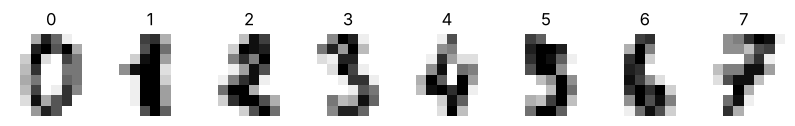

In [19]:
digits = load_digits()

fig, axes = plt.subplots(1, 8, figsize=(10, 2))
for ax, img, label in zip(axes, digits.images, digits.target):
    ax.imshow(img, cmap="gray_r")
    ax.set_title(label)
    ax.axis("off")
plt.show()

In [20]:
digits.images[0].shape, digits.data[0].shape    # same pixels, 2D vs flattened

((8, 8), (64,))

Wine as a DataFrame:

In [21]:
X, y = load_wine(return_X_y=True, as_frame=True)
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: float64(13)
m

In [22]:
y.value_counts().sort_index()   # not balanced like iris

target
0    59
1    71
2    48
Name: count, dtype: int64

## Fetchers

These download the data the first time and store it in `~/scikit_learn_data` (see
`sklearn.datasets.get_data_home()`), so the second call is fast.

The outputs in this section are from my Colab run.

### California housing

In [23]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

In [24]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

    :Number of Instances: 20640

    :Number of Attributes: 8 numeric, predictive attributes and the target

    :Attribute Information:
        - MedInc        median income in block group
        - HouseAge      median house age in block group
        - AveRooms      average number of rooms per household
        - AveBedrms     average number of bedrooms per household
        - Population    block group population
        - AveOccup      average number of household members
        - Latitude      block group latitude
        - Longitude     block group longitude

    :Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived

In [25]:
housing.data.shape

(20640, 8)

In [26]:
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [27]:
housing.data[:5]

array([[ 8.32520000e+00,  4.10000000e+01,  6.98412698e+00,
         1.02380952e+00,  3.22000000e+02,  2.55555556e+00,
         3.78800000e+01, -1.22230000e+02],
       [ 8.30140000e+00,  2.10000000e+01,  6.23813708e+00,
         9.71880492e-01,  2.40100000e+03,  2.10984183e+00,
         3.78600000e+01, -1.22220000e+02],
       [ 7.25740000e+00,  5.20000000e+01,  8.28813559e+00,
         1.07344633e+00,  4.96000000e+02,  2.80225989e+00,
         3.78500000e+01, -1.22240000e+02],
       [ 5.64310000e+00,  5.20000000e+01,  5.81735160e+00,
         1.07305936e+00,  5.58000000e+02,  2.54794521e+00,
         3.78500000e+01, -1.22250000e+02],
       [ 3.84620000e+00,  5.20000000e+01,  6.28185328e+00,
         1.08108108e+00,  5.65000000e+02,  2.18146718e+00,
         3.78500000e+01, -1.22250000e+02]])

In [28]:
housing.target[:5]

array([4.526, 3.585, 3.521, 3.413, 3.422])

The target is continuous (median house value in units of $100,000), so this is a regression dataset.

### OpenML

[openml.org](https://www.openml.org) hosts thousands of public datasets. `fetch_openml` pulls any of them
by name or id. MNIST is about 50 MB, so the first download takes a while.

In [29]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml("mnist_784", version=1, return_X_y=True)
print("Feature matrix shape:", X.shape)
print("Label shape:", y.shape)

Feature matrix shape: (70000, 784)
Label shape: (70000,)


In [30]:
X, y = fetch_openml("credit-g", version=1, return_X_y=True)
print("Feature matrix shape:", X.shape)
print("Label shape:", y.shape)

Feature matrix shape: (1000, 20)
Label shape: (1000,)


Other fetchers worth knowing: `fetch_20newsgroups` (text classification), `fetch_lfw_people` (faces),
`fetch_covtype`, `fetch_kddcup99`.

## Generators

Useful for testing an idea on data where you know the answer. Always pass `random_state` so the
data is the same every run.

### make_regression

In [31]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100, n_features=5, n_targets=1, noise=10, random_state=42)
X.shape, y.shape

((100, 5), (100,))

In [32]:
# 5 targets per sample -> y becomes 2D
X, y = make_regression(n_samples=100, n_features=5, n_targets=5, random_state=42)
X.shape, y.shape

((100, 5), (100, 5))

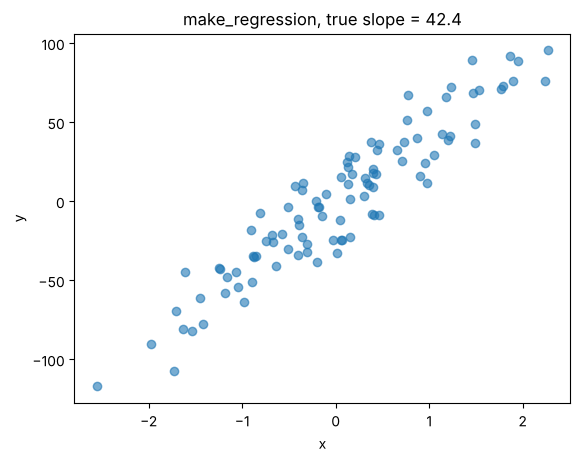

In [33]:
# one feature, so it can be plotted
X, y, coef = make_regression(n_samples=100, n_features=1, noise=15, coef=True, random_state=0)

plt.scatter(X, y, alpha=0.6)
plt.title(f"make_regression, true slope = {coef:.1f}")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

### make_classification

`n_informative` features actually carry the signal, `n_redundant` are linear combinations of those,
the rest is noise.

In [34]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=100, n_features=10, n_classes=2,
                           n_clusters_per_class=1, random_state=42)
X.shape, np.bincount(y)

((100, 10), array([50, 50]))

In [35]:
X, y = make_classification(n_samples=100, n_features=10, n_classes=3,
                           n_clusters_per_class=1, random_state=42)
X.shape, np.bincount(y)

((100, 10), array([34, 33, 33]))

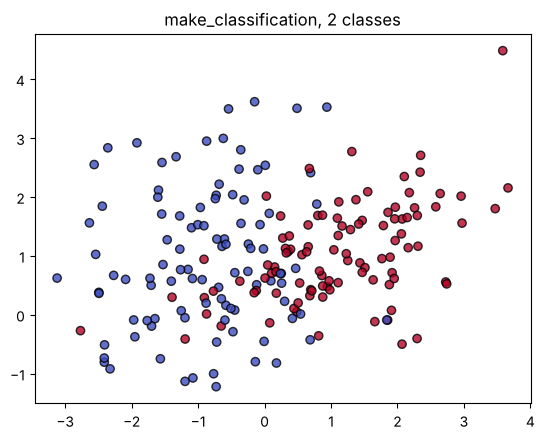

In [36]:
# 2 informative features and nothing else, so it can be plotted
X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", alpha=0.8)
plt.title("make_classification, 2 classes")
plt.show()

`weights` makes an imbalanced problem, which comes up again in the preprocessing notebook:

In [37]:
X, y = make_classification(n_samples=1000, n_features=4, weights=[0.95], flip_y=0, random_state=1)
np.bincount(y)

array([950,  50])

### make_multilabel_classification

Each sample can belong to several classes at once (think movie genres), so `y` is a 0/1 matrix with one
column per label.

In [38]:
from sklearn.datasets import make_multilabel_classification

X, y = make_multilabel_classification(n_samples=100, n_features=20, n_classes=5,
                                      n_labels=2, random_state=42)
X.shape, y.shape

((100, 20), (100, 5))

In [39]:
y[:5]

array([[0, 0, 0, 1, 0],
       [1, 1, 1, 0, 0],
       [0, 0, 1, 1, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 1, 0, 0]])

In [40]:
y.sum(axis=1).mean()    # average labels per sample, close to n_labels=2

np.float64(1.79)

### make_blobs

Gaussian clusters, mainly for clustering. `y` is which blob each point came from.

X: (300, 2)  y: (300,)  clusters: [0 1 2]


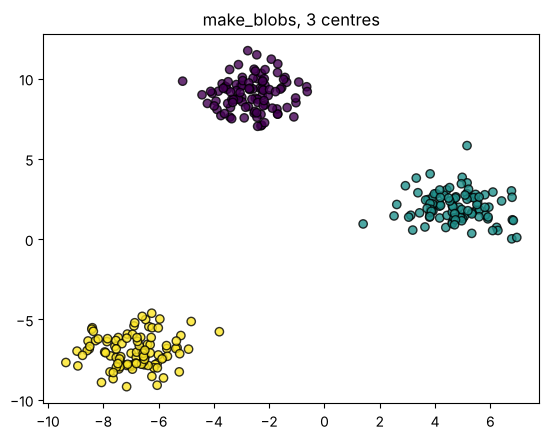

In [41]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)
print("X:", X.shape, " y:", y.shape, " clusters:", np.unique(y))

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolor="k", alpha=0.8)
plt.title("make_blobs, 3 centres")
plt.show()

### Non-linear shapes

`make_moons` and `make_circles` are the standard "a straight line can't separate this" examples.

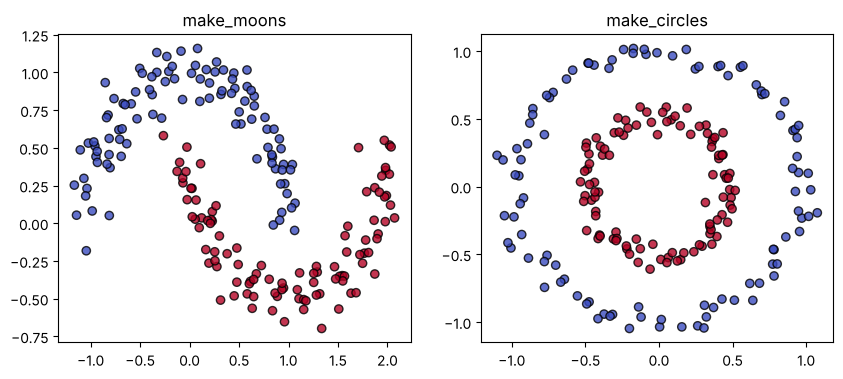

In [42]:
from sklearn.datasets import make_moons, make_circles

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (X, y), title in zip(axes,
                             [make_moons(200, noise=0.1, random_state=0),
                              make_circles(200, noise=0.05, factor=0.5, random_state=0)],
                             ["make_moons", "make_circles"]):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", alpha=0.8)
    ax.set_title(title)
plt.show()

## Summary

| | returns | needs internet | examples |
|---|---|---|---|
| `load_*` | Bunch (or X, y) | no | iris, diabetes, digits, wine, breast_cancer, linnerud |
| `fetch_*` | Bunch (or X, y) | first time only | california_housing, openml, 20newsgroups |
| `make_*` | X, y | no | regression, classification, blobs, moons, circles |

Useful arguments: `return_X_y=True`, `as_frame=True`, and `random_state` for the generators.

## References

* [sklearn dataset loading utilities](https://scikit-learn.org/stable/datasets.html)
* [API design for machine learning software: experiences from the scikit-learn project](https://arxiv.org/abs/1309.0238)